# Basic Raster Styling and Analysis with Xarray

## Introduction

[`rioxarray`](https://corteva.github.io/rioxarray/stable/) and [`xarray-spatial`](https://xarray-spatial.readthedocs.io/en/stable/) extensions provide core functionality for working with geospatial rasters using Xarray. In this tutorial, we will use these to read, analyze and reclassify population rasters.

## Overview of the Task

We will use the [Gridded Population of the World (GPW) v4](https://sedac.ciesin.columbia.edu/data/collection/gpw-v4) dataset from Columbia University. Specifically, the [Population Count](https://sedac.ciesin.columbia.edu/data/set/gpw-v4-population-count-rev11/data-download) for the entire globe at 2.5 Minute (~5Km) resolution in GeoTiFF format and for the year 2010 and 2020. Using these we will create a thematic map of the global population change between year 2010 and 2020.

**Input Layers**:
*   `gpw-v4-population-count-rev11_YYYY_2pt5_min_tif.zip`: Zipped Raster files having population data.

**Output**:
*   `change_class.tif` : A GeoTIFF file of categorized population change.

**Data Credit**:
*   Center for International Earth Science Information Network - CIESIN - Columbia University. 2018. Gridded Population of the World, Version 4 (GPWv4): Population Count, Revision 11. Palisades, NY: NASA Socioeconomic Data and Applications Center (SEDAC). https://doi.org/10.7927/H4JW8BX5. Accessed 27 JUNE 2019

**Running the Notebook**:
The preferred way to run this notebook is on Google Colab.
<a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/xarray_raster_styling_analysis.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Watch Video Walkthrough**: Watch a detailed explanation of the workflow. <a href='https://www.youtube.com/watch?v=l1Q3gKnH5Ik' target='_blank'><i class='fab fa-youtube' style='color: red; font-size: 1.5em;'></i> YouTube</a>

## Setup and Data Download
The following blocks of code will install the required packages and download the datasets to your Colab environment.


In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install rioxarray xarray-spatial

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import rioxarray as rxr
import xrspatial
import zipfile

In [3]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

In [4]:
def download(url):
    filename = os.path.join(data_folder, os.path.basename(url))
    if not os.path.exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

data_url = 'https://github.com/spatialthoughts/geopython-tutorials/releases/download/data/'

gpw_pop_2010 = 'gpw-v4-population-count-rev11_2010_2pt5_min_tif.zip'
gpw_pop_2020 = 'gpw-v4-population-count-rev11_2020_2pt5_min_tif.zip'

download(data_url + gpw_pop_2010)
download(data_url + gpw_pop_2020)

Downloaded data/gpw-v4-population-count-rev11_2010_2pt5_min_tif.zip
Downloaded data/gpw-v4-population-count-rev11_2020_2pt5_min_tif.zip


## Procedure

Read the gridded population of the World files using the `rioxarray` by using [open_raster](https://docs.xarray.dev/en/stable/generated/xarray.open_rasterio.html) function. We can read the GeoTIFF file directly from the zip archive without uncompressing it first by creating a URI with the `zip://` prefix.

In [9]:
gpw_pop_2010_path = os.path.join(data_folder, gpw_pop_2010)

with zipfile.ZipFile(gpw_pop_2010_path) as f:
  files = f.namelist()
  # print(files)
  for file in files:
    if os.path.splitext(file)[1] == '.tif':
      tif_file = file

gpw_pop_2010_uri = 'zip://{}!{}'.format(gpw_pop_2010_path, tif_file)
# print(gpw_pop_2010_uri)
pop2010 = rxr.open_rasterio(gpw_pop_2010_uri, mask_and_scale=True)

zip://data/gpw-v4-population-count-rev11_2010_2pt5_min_tif.zip!gpw_v4_population_count_rev11_2010_2pt5_min.tif


In [13]:
gpw_pop_2020_path = os.path.join(data_folder, gpw_pop_2020)

with zipfile.ZipFile(gpw_pop_2020_path) as f:
  files = f.namelist()
  for file in files:
    if os.path.splitext(file)[1] == '.tif':
      tif_file = file

gpw_pop_2020_uri = 'zip://{}!{}'.format(gpw_pop_2020_path, tif_file)
pop2020 = rxr.open_rasterio(gpw_pop_2020_uri, mask_and_scale=True, chunks="auto")
pop2020

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
dask.array<open_rasterio-b353c7ba0d862ec30339d1cdbfe28d57<this-array>, shape=(1, 4320, 8640), dtype=float32, chunksize=(1, 3883, 8640), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC

Now we will take the difference of the population

In [20]:
change = pop2020 - pop2010
# change.sel(band=1)

`change` is a 3D array containing 1-band with pixel values with the population count different between the 2 years. We select the `band1` and visualize it using Xarray's [`imshow()`](https://docs.xarray.dev/en/stable/generated/xarray.plot.imshow.html) method.

The values range from negative (reduction in population) to positive (increate in population). Since we are plotting diverging values, we can use a **Spectral** color ramp. We can anchor the visualization to a min/max range using `vmin` and `vmax` values. It is important to specify a `center` value so that the color ramp is centered at the specified value.

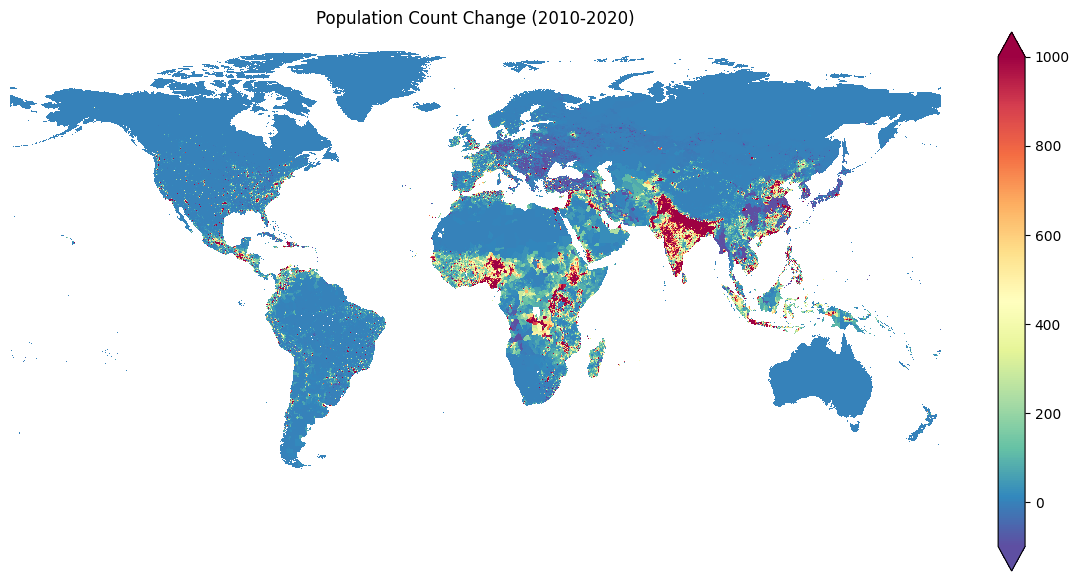

In [22]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,7)

change.sel(band=1).plot.imshow(
    ax=ax, vmin=-100, vmax=1000, center=0,
    add_colorbar=True, cmap='Spectral_r')
ax.set_title('Population Count Change (2010-2020)')
ax.set_axis_off()

plt.show()

This is a good visualization, but not easy to interpret. Let’s create a better map with 4 discrete categories:

* **Negative**: Negative Cange upto -100.
* **Neutral**: Insignificant Negative or Positive Change between -100 to +100
* **Growth**: Small Positive Change between 100 to 1000.
* **High Growth**: Large Positive Change greater than 1000.

We use Xarray Spatial's [`reclassify()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.classify.reclassify.html) method to perform the reclassification from continuous values to 4 discrete classes.



In [23]:
class_bins = [-100, 100, 1000, np.inf]
class_values = [1, 2, 3, 4]
change_class = xrspatial.classify.reclassify(
    change.sel(band=1), bins=class_bins, new_values=class_values)

The result is a 2D array of reclassified values. We can visualize it the same way as before.

Since we have discrete pixel values, we can assign a specific color to each class using the `levels` parameter. The `levels` list defines the boundary of each interval and the `colors` list defines the colors assigned to each interval.

* Interval 1: Values between 1 and 2 (Decline)
* Interval 2: Values between 2 and 3 (Neutral)
* Interval 3: Values between 3 and 4 (Growth)
* Interval 4: Values between 4 and 5 (High Growth)


The `imshow` method supports only a colorbar legend which is not appropriate for a discrete classified raster such as ours. We use Matplotlib's [`Patch()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Patch.html) method to create a patch with appropriate labels and colors as described in Matplotlib's [Legend guide](https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html).

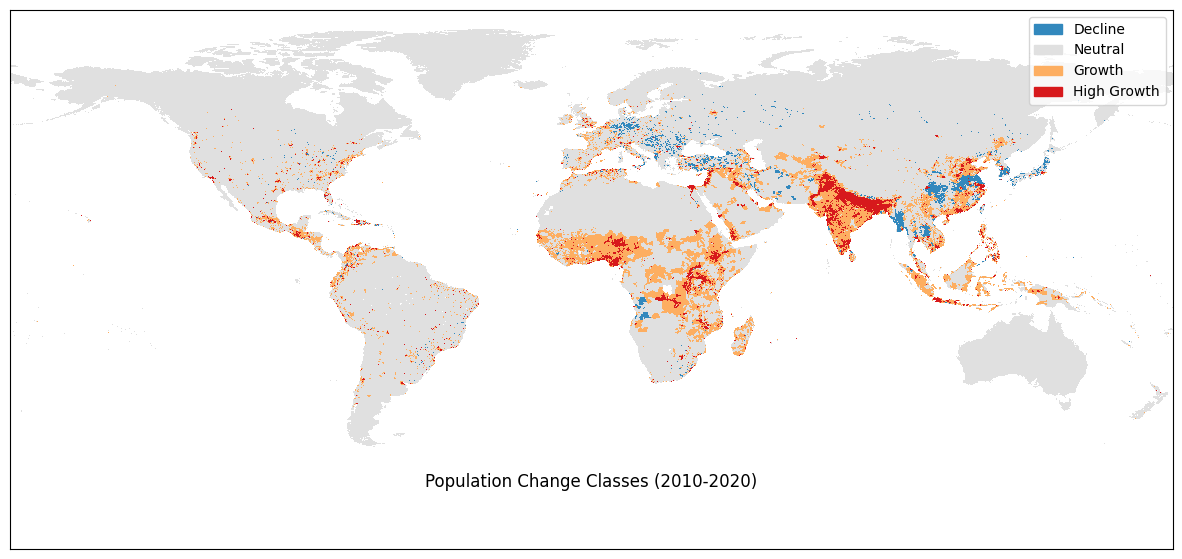

In [24]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,7)

levels = np.linspace(
    min(class_values), max(class_values) + 1, len(class_values) + 1)

colors = ['#3288bd', '#e0e0e0', '#fdae61', '#d7191c']
labels = ['Decline', 'Neutral', 'Growth', 'High Growth']

change_class.plot.imshow(
    ax=ax,
    add_colorbar=False,
    levels=levels,
    vmin=1,
    colors=colors)


patches =[mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
ax.legend(handles=patches)
ax.set_title('Population Change Classes (2010-2020)', y=0.1)

# Set axis labels off
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

In [26]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


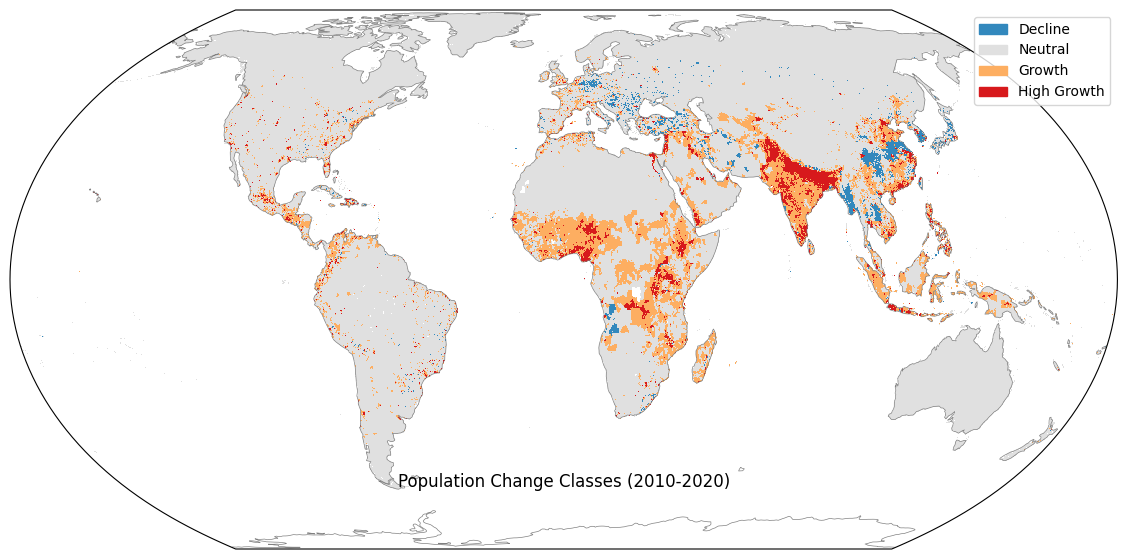

In [27]:
import cartopy.crs as ccrs

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.EqualEarth()})
fig.set_size_inches(15, 7)

levels = np.linspace(
    min(class_values), max(class_values) + 1, len(class_values) + 1)

colors = ['#3288bd', '#e0e0e0', '#fdae61', '#d7191c']
labels = ['Decline', 'Neutral', 'Growth', 'High Growth']

change_class.plot.imshow(
    ax=ax,
    add_colorbar=False,
    levels=levels,
    vmin=1,
    colors=colors,
    transform=ccrs.PlateCarree()  # tells cartopy the data is in lat/lon
)

patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
ax.legend(handles=patches)
ax.set_title('Population Change Classes (2010-2020)', y=0.1)

ax.coastlines(linewidth=0.5, color='gray')  # optional: adds context
ax.set_global()  # ensures full globe is shown

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

Last step is to save the results to disk as a GeoTiff file.

In [28]:
output_file = 'change_class.tif'
output_file_path = os.path.join(output_folder, output_file)
change_class.rio.to_raster(output_file_path, compress='LZW')

In [29]:
from rioxarray.rioxarray import CRS

# Reproject to Equal Earth
change_class_ee = change_class.rio.reproject("ESRI:54035")

# Save
output_file = 'change_class_equal_earth.tif'
output_file_path = os.path.join(output_folder, output_file)
change_class_ee.rio.to_raster(output_file_path, compress='LZW')

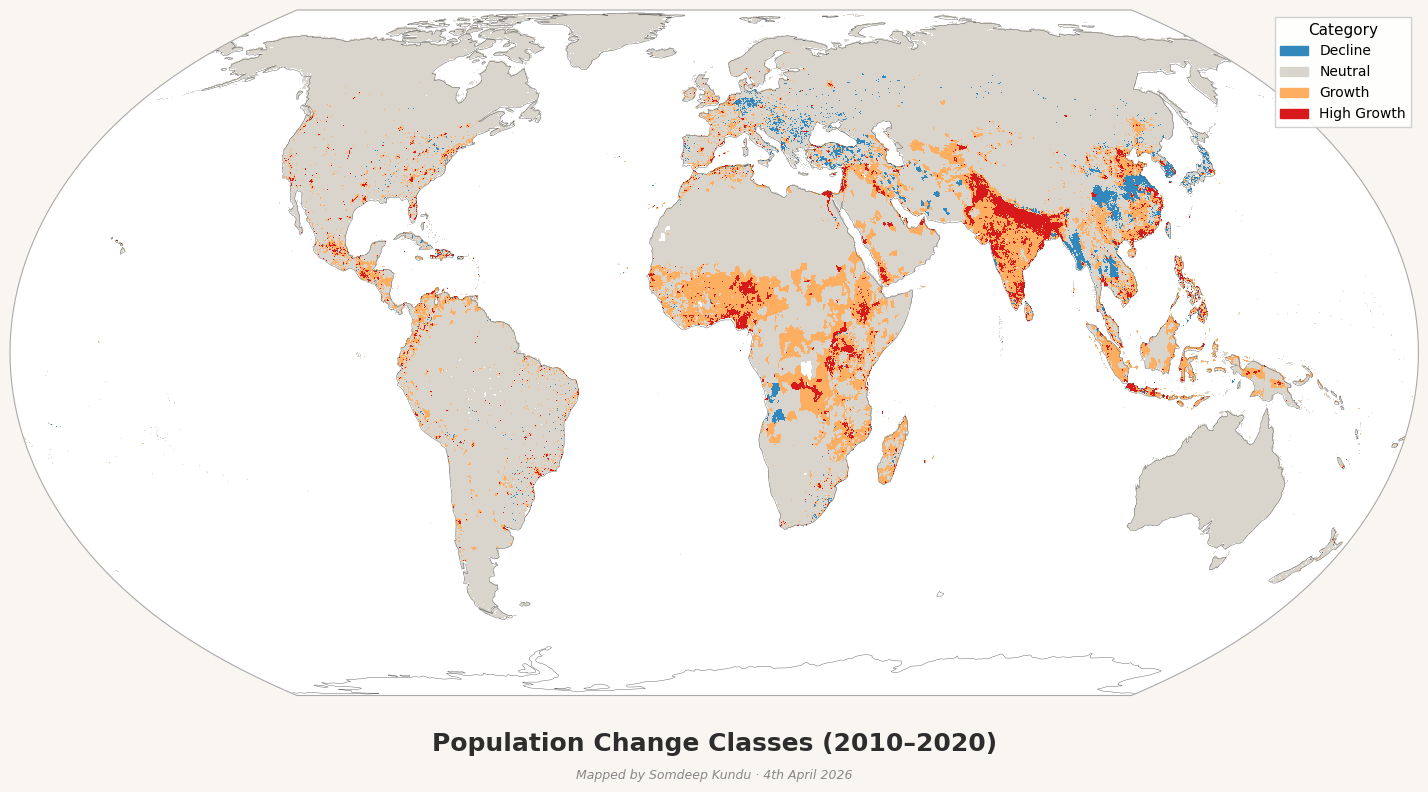

In [32]:
import cartopy.crs as ccrs
import matplotlib.font_manager as fm

# Use a clean sans-serif font
# plt.rcParams['font.family'] = 'Helvetica'
# Fallback if Helvetica isn't available:
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.EqualEarth()})
fig.set_size_inches(16, 8)
fig.patch.set_facecolor('#f9f6f1')  # warm off-white background

levels = np.linspace(
    min(class_values), max(class_values) + 1, len(class_values) + 1)

colors = ['#3288bd', '#d9d5cc', '#fdae61', '#d7191c']
labels = ['Decline', 'Neutral', 'Growth', 'High Growth']

change_class.plot.imshow(
    ax=ax,
    add_colorbar=False,
    levels=levels,
    vmin=1,
    colors=colors,
    transform=ccrs.PlateCarree()
)

# Legend — placed top-right, clean styling
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
legend = ax.legend(
    handles=patches,
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fontsize=10,
    title='Category',
    title_fontsize=11,
    fancybox=False,
)

# Subtle coastlines
ax.coastlines(linewidth=0.3, color='#555555')
ax.set_global()

# Title — larger, bolder, positioned at bottom-center of map
ax.set_title(
    'Population Change Classes (2010–2020)',
    fontsize=18,
    fontweight='bold',
    color='#2d2d2d',
    y=-0.02,
    pad=-30
)

# Attribution line at the very bottom
fig.text(
    0.5, 0.02,
    'Mapped by Somdeep Kundu · 4th April 2026',
    ha='center',
    fontsize=9,
    color='#888888',
    style='italic'
)

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

# Outline of the globe
ax.spines['geo'].set_edgecolor('#aaaaaa')
ax.spines['geo'].set_linewidth(0.8)

plt.tight_layout(rect=[0, 0.04, 1, 1])  # leave room for attribution
plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


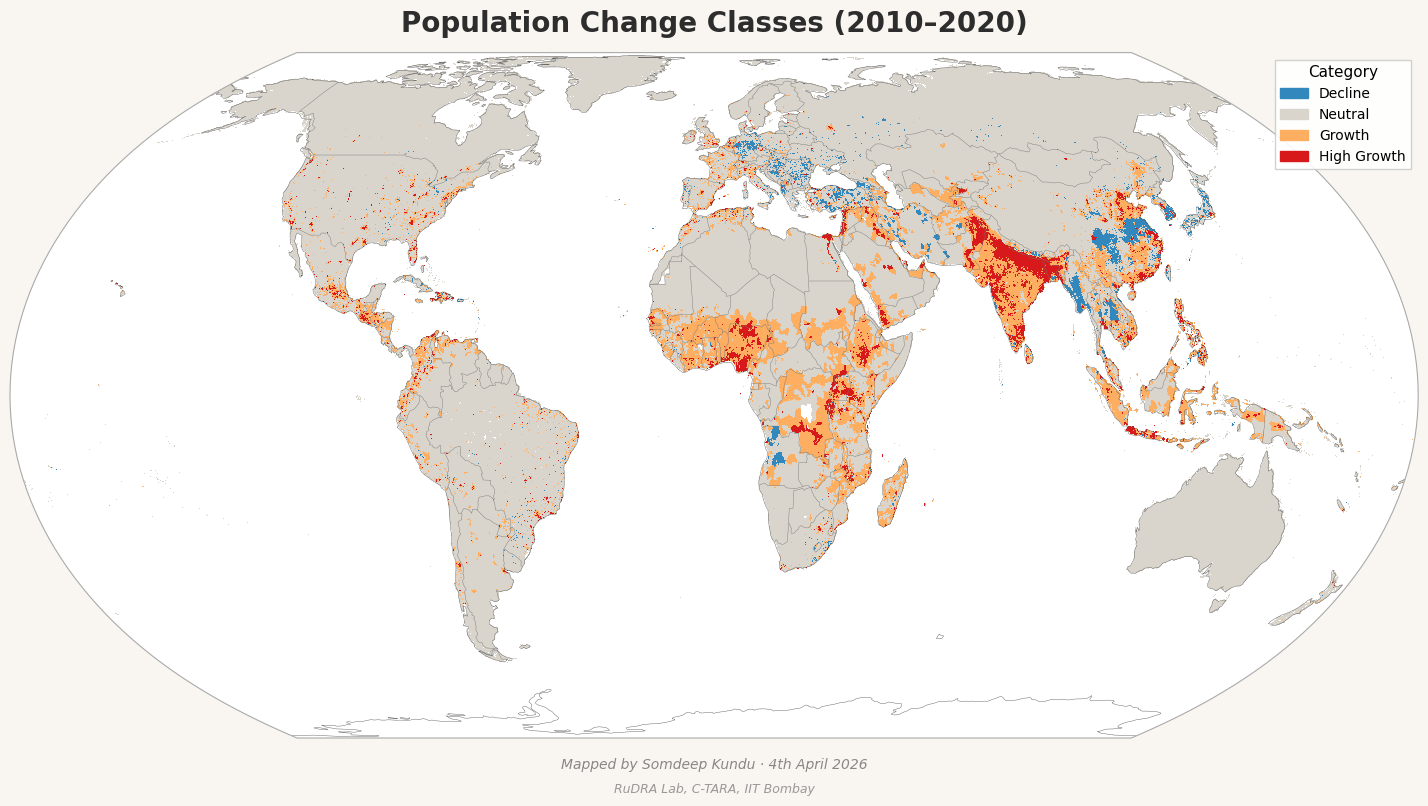

In [34]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.EqualEarth()})
fig.set_size_inches(16, 8)
fig.patch.set_facecolor('#f9f6f1')

levels = np.linspace(
    min(class_values), max(class_values) + 1, len(class_values) + 1)

colors = ['#3288bd', '#d9d5cc', '#fdae61', '#d7191c']
labels = ['Decline', 'Neutral', 'Growth', 'High Growth']

change_class.plot.imshow(
    ax=ax,
    add_colorbar=False,
    levels=levels,
    vmin=1,
    colors=colors,
    transform=ccrs.PlateCarree()
)

# Legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
legend = ax.legend(
    handles=patches,
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fontsize=10,
    title='Category',
    title_fontsize=11,
    fancybox=False,
)

# Coastlines + country boundaries
ax.coastlines(linewidth=0.3, color='#555555')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#777777', linestyle='-')
ax.set_global()

# Title at the TOP
ax.set_title(
    'Population Change Classes (2010–2020)',
    fontsize=20,
    fontweight='bold',
    color='#2d2d2d',
    pad=15
)

# Attribution lines at the bottom
fig.text(
    0.5, 0.04,
    'Mapped by Somdeep Kundu · 4th April 2026',
    ha='center',
    fontsize=10,
    color='#888888',
    style='italic'
)
fig.text(
    0.5, 0.01,
    'RuDRA Lab, C-TARA, IIT Bombay',
    ha='center',
    fontsize=9,
    color='#999999',
    style='italic'
)

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

ax.spines['geo'].set_edgecolor('#aaaaaa')
ax.spines['geo'].set_linewidth(0.8)

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(
    os.path.join(output_folder, 'population_change_equal_earth.png'),
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
    pad_inches=0.3
)

plt.show()

In [35]:
import urllib.request, os

shp_dir = 'india_shp'
os.makedirs(shp_dir, exist_ok=True)

base_url = 'https://raw.githubusercontent.com/somdeepkundu/geoKosh/main/IndiaShapes/'

for ext in ['shp', 'dbf', 'prj', 'shx']:
    url = f'{base_url}IndiaBorder.{ext}'
    urllib.request.urlretrieve(url, f'{shp_dir}/IndiaBorder.{ext}')
    print(f'Downloaded IndiaBorder.{ext}')

Downloaded IndiaBorder.shp
Downloaded IndiaBorder.dbf
Downloaded IndiaBorder.prj
Downloaded IndiaBorder.shx


In [36]:
india_shp_path = 'india_shp/IndiaBorder.shp'

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.collections import PatchCollection
from cartopy.feature import ShapelyFeature
import geopandas as gpd

plt.rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.EqualEarth()})
fig.set_size_inches(16, 8)
fig.patch.set_facecolor('#f9f6f1')

levels = np.linspace(
    min(class_values), max(class_values) + 1, len(class_values) + 1)

colors = ['#3288bd', '#d9d5cc', '#fdae61', '#d7191c']
labels = ['Decline', 'Neutral', 'Growth', 'High Growth']

change_class.plot.imshow(
    ax=ax,
    add_colorbar=False,
    levels=levels,
    vmin=1,
    colors=colors,
    transform=ccrs.PlateCarree()
)

# Legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
legend = ax.legend(
    handles=patches,
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fontsize=10,
    title='Category',
    title_fontsize=11,
    fancybox=False,
)

# --- Boundaries ---
# 1. All other countries — default Natural Earth
ax.coastlines(linewidth=0.3, color='#555555')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#777777', linestyle='-')

# 2. Official India boundary (SOI shapefile)
# Update this path to your shapefile location
india_shp_path = 'india_shp/IndiaBorder.shp'  # <-- UPDATE THIS

india_gdf = gpd.read_file(india_shp_path)
india_feature = ShapelyFeature(
    india_gdf.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#333333',
    linewidth=0.8,
)
ax.add_feature(india_feature)

ax.set_global()

# Title at the top
ax.set_title(
    'Population Change Classes (2010–2020)',
    fontsize=20,
    fontweight='bold',
    color='#2d2d2d',
    pad=15
)

# Attribution
fig.text(
    0.5, 0.04,
    'Mapped by Somdeep Kundu · 4th April 2026',
    ha='center', fontsize=10, color='#888888', style='italic'
)
fig.text(
    0.5, 0.01,
    'RuDRA Lab, C-TARA, IIT Bombay',
    ha='center', fontsize=9, color='#999999', style='italic'
)

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.spines['geo'].set_edgecolor('#aaaaaa')
ax.spines['geo'].set_linewidth(0.8)

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(
    os.path.join(output_folder, 'population_change_equal_earth.png'),
    dpi=300, bbox_inches='tight',
    facecolor=fig.get_facecolor(), pad_inches=0.3
)
plt.show()

----

If you want to give feedback or share your experience with this tutorial, please comment below. (requires GitHub account)


<script src='https://utteranc.es/client.js'
    repo='spatialthoughts/geopython-tutorials'
    issue-term='pathname'
    theme='github-light'
    crossorigin='anonymous'
    async>
</script>